# SDM-VA-ISAC — Phase 2 : Sionna RT Pipeline sur riad.xml

**Projet :** *Semantic Digital Mapping using Vision-Assisted ISAC*  
**Phase :** 2 — Scène Blender/OSM→XML + calibration Sionna RT  
**Scène :** `riad.xml` exportée depuis Blender via Mitsuba-Blender add-on  
**Zone :** Secteur gouvernemental de Rabat (Conseil Économique, Cour des Comptes…)

### Objectifs de ce notebook
1. Charger `riad.xml` dans Sionna RT avec variante GPU `cuda_ad_mono_polarized`
2. Configurer les paramètres RF : 3.5 GHz (5G mid-band) ou 28 GHz (mmWave)
3. Déployer BS (TX) et UE (RX), lancer le ray tracing
4. Extraire CIR, délais, puissances — sorties ISAC pour la Phase 3
5. Visualiser PDP, couverture de puissance, trajets

### Critères de validation Phase 2
- [ ] Scène XML chargée sans erreur
- [ ] PathSolver retourne des chemins exploitables
- [ ] CIR extrait avec dimensions cohérentes
- [ ] Graphe PDP (Power Delay Profile) généré
- [ ] `phase2_sionna_rt_summary.json` produit pour la Phase 3

## 1. Imports et configuration de l'environnement

In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Mitsuba : variante GPU (RTX 4070 → cuda_ad_mono_polarized)
# Sionna RT 2.x nécessite 'mono_polarized', PAS 'rgb'
import mitsuba as mi

try:
    mi.set_variant("cuda_ad_mono_polarized")
    print(f"Variante GPU activée : {mi.variant()}")
except Exception as e:
    print(f"CUDA indisponible ({e}), repli sur LLVM CPU")
    mi.set_variant("llvm_ad_mono_polarized")
    print(f"Variante CPU activée : {mi.variant()}")

# ── Sionna RT 2.0.1
import sionna
from sionna.rt import (
    load_scene,
    Transmitter, Receiver,
    PlanarArray,
    PathSolver,
    RadioMapSolver, PlanarRadioMap,
    Camera,
)

print(f"Sionna version : {sionna.__version__}")

# ── Chemins
WORKSPACE = Path(r"C:\Users\AdminFix\Desktop\PFA")
SCENE_XML  = WORKSPACE / "riad.xml"        # scène exportée depuis Blender

# ── Paramètres RF
FREQUENCY_HZ  = 3.5e9    # 3.5 GHz — 5G NR mid-band (changer à 28e9 pour mmWave)
BANDWIDTH_HZ  = 20e6     # 20 MHz
MAX_DEPTH     = 5        # profondeur max des trajets (réflexions + diffractions)

assert SCENE_XML.exists(), f"Fichier introuvable : {SCENE_XML}"
print(f"Scène : {SCENE_XML}")
print(f"Fréquence : {FREQUENCY_HZ/1e9:.1f} GHz | BW : {BANDWIDTH_HZ/1e6:.0f} MHz")

jitc_llvm_init(): LLVM API initialization failed ..


Variante GPU activée : cuda_ad_mono_polarized
Sionna version : 2.0.1
Scène : C:\Users\AdminFix\Desktop\PFA\riad.xml
Fréquence : 3.5 GHz | BW : 20 MHz


## 2. Chargement de la scène riad.xml

La scène contient les maillages PLY des bâtiments avec matériaux ITU :
- `itu_concrete` → sol (Plane.ply)
- `itu_marble` → façades de bâtiments
- `itu_metal` → toits et éléments métalliques

Sionna RT reconnaît automatiquement les matériaux préfixés `itu_`.

In [7]:
print("Chargement de la scène...")
t0 = time.time()

scene = load_scene(
    str(SCENE_XML),
    merge_shapes=True,
    remove_duplicate_vertices=False,
)

print(f"Scène chargée en {time.time()-t0:.2f} s")
print(f"Objets dans la scène : {list(scene.objects.keys())[:10]}...")
print(f"Matériaux radio : {list(scene.radio_materials.keys())}")

scene.frequency = FREQUENCY_HZ
scene.bandwidth = BANDWIDTH_HZ
# Utiliser les variables Python directement (scene.frequency retourne mi.Float)
print(f"\nFréquence scène : {FREQUENCY_HZ/1e9:.2f} GHz")
print(f"Bande passante  : {BANDWIDTH_HZ/1e6:.0f} MHz")

Chargement de la scène...
Scène chargée en 0.58 s
Objets dans la scène : ['elm__3', 'no-name-7', 'no-name-8']...
Matériaux radio : ['itu_concrete', 'itu_marble', 'itu_metal']

Fréquence scène : 3.50 GHz
Bande passante  : 20 MHz


## 3. Configuration des réseaux d'antennes et placement des équipements

- **BS (TX)** : réseau planaire 4×4, dual-polarisé, hauteur 25 m (macro-cellule)
- **UE (RX)** : antenne simple, hauteur 1.5 m (piéton/véhicule)

Les positions sont en mètres dans le repère local Blender.
Ajustez `TX_POS` et `RX_POSITIONS` selon votre carte OSM.

In [ ]:
# ── Bounding box réelle de la scène (issue de scene._scene.bbox())
# X: [-805, +795]  Y: [-839, +761]  Z: [0, 21 m]
# Centre scène ≈ (-5, -39)  |  Taille : 1600×1600 m  |  Bâtiments ≤ 21 m

# ── Réseaux d'antennes
bs_array = PlanarArray(
    num_rows=4, num_cols=4,
    vertical_spacing=0.5, horizontal_spacing=0.5,
    pattern="tr38901", polarization="VH",
)
ue_array = PlanarArray(
    num_rows=1, num_cols=1,
    vertical_spacing=0.5, horizontal_spacing=0.5,
    pattern="tr38901", polarization="V",
)
scene.tx_array = bs_array
scene.rx_array = ue_array

# ── BS au centre de la scène, 5 m au-dessus du toit le plus haut (21 m)
TX_POS = [-5.0, -39.0, 30.0]

# ── UE à 1.5 m (hauteur piéton), dispersés dans la scène
# Distances choisies pour couvrir LOS proche, NLOS moyen, et bord de scène
RX_POSITIONS = [
    [ -5.0,  61.0, 1.5],    # UE0 — 100 m nord  (LOS probable)
    [ -5.0, -139.0, 1.5],   # UE1 — 100 m sud   (LOS probable)
    [ 195.0, -39.0, 1.5],   # UE2 — 200 m est   (NLOS possible)
    [-205.0, -39.0, 1.5],   # UE3 — 200 m ouest (NLOS possible)
    [ 145.0,  61.0, 1.5],   # UE4 — 200 m NE diagonal
]

# ── Ajouter à la scène
tx = Transmitter(name="bs0", position=TX_POS)
scene.add(tx)
print(f"TX ajouté : bs0 @ {TX_POS}  (centre scène + 30 m hauteur)")

for i, pos in enumerate(RX_POSITIONS):
    scene.add(Receiver(name=f"ue{i}", position=pos))
    print(f"RX ajouté : ue{i} @ {pos}")

print(f"\nTotal TX : {len(scene.transmitters)} | Total RX : {len(scene.receivers)}")

## 4. Lancer de rayons (Ray Tracing)

Le `PathSolver` calcule tous les trajets entre TX et RX :
- **LOS** : trajet en ligne de vue directe
- **Specular reflection** : réflexions spéculaires sur façades
- **Diffraction** : contournement des arêtes de bâtiments
- **Diffuse reflection** : activée pour des scènes plus réalistes (coûteux)

> Pour `max_depth=5` : jusqu'à 4 réflexions + 1 diffraction par trajet.

In [9]:
solver = PathSolver()

print(f"Calcul des trajets (max_depth={MAX_DEPTH})...")
t0 = time.time()

paths = solver(
    scene,
    max_depth=MAX_DEPTH,
    los=True,                   # trajets LOS
    specular_reflection=True,   # réflexions spéculaires
    diffuse_reflection=False,   # désactivé (activer pour + de réalisme)
    refraction=False,           # désactivé (bâtiments opaques)
    diffraction=True,           # diffraction sur arêtes
    edge_diffraction=False,     # diffraction sur arêtes flottantes
    seed=42,
)

elapsed = time.time() - t0
print(f"Ray tracing terminé en {elapsed:.2f} s")

# Afficher les infos sur les trajets trouvés
tau_raw = np.array(paths.tau)   # [num_rx, num_tx, num_paths] (synthetic_array=True)
print(f"\nShape tau : {tau_raw.shape}  → [num_rx, num_tx, num_paths]")
print(f"Nombre de trajets par lien RX-TX : {tau_raw.shape[-1]}")

# Compter les trajets valides (tau > 0)
valid_mask = tau_raw > 0
print(f"Trajets valides : {valid_mask.sum()} / {valid_mask.size}")

Calcul des trajets (max_depth=5)...
Ray tracing terminé en 1.33 s

Shape tau : (5, 1, 160)  → [num_rx, num_tx, num_paths]
Nombre de trajets par lien RX-TX : 160
Trajets valides : 538 / 800


## 5. Extraction de la réponse impulsionnelle (CIR)

`paths.cir()` retourne le CIR en bande de base équivalente :
- `a` = tuple `(a_real, a_imag)` — coefficients complexes de chaque trajet
- `tau` = délais [s]
- Shape : `[num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]`

Pour le ISAC : on extrait délai, puissance, et DoA de chaque trajet.

In [10]:
# CIR en bande de base — out_type="numpy" retourne un tableau complexe directement
# a_complex : [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
# tau_cir   : [num_rx, num_tx, num_paths]  (synthetic_array=True)
a_complex, tau_cir = paths.cir(
    sampling_frequency=BANDWIDTH_HZ,
    num_time_steps=1,
    normalize_delays=True,      # premier trajet à τ=0 par paire TX-RX
    out_type="numpy",
)

print("CIR extrait :")
print(f"  a_complex.shape : {a_complex.shape}")
print(f"  a_complex.dtype : {a_complex.dtype}")
print(f"  tau_cir.shape   : {tau_cir.shape}")

num_rx   = a_complex.shape[0]
num_tx   = a_complex.shape[2]
num_path = a_complex.shape[4]

print(f"\n  num_rx={num_rx}, num_tx={num_tx}, num_paths={num_path}")

# ── Statistiques pour le lien UE0 ← BS0
# a_complex[rx, rx_ant, tx, tx_ant, paths, time]
a_link   = a_complex[0, :, 0, :, :, 0]   # [rx_ant, tx_ant, num_paths]
tau_link = tau_cir[0, 0, :]               # [num_paths]

power_link  = np.abs(a_link)**2
total_power = power_link.sum()
valid_mask  = tau_link >= 0

print(f"\nLien UE0←BS0 :")
print(f"  Trajets valides         : {valid_mask.sum()} / {num_path}")
print(f"  Puissance totale reçue  : {10*np.log10(total_power + 1e-30):.1f} dB (rel.)")
if valid_mask.sum() > 0:
    print(f"  Délai max               : {1e9 * tau_link[valid_mask].max():.1f} ns")
    print(f"  Délai moyen (RMS)       : {1e9 * np.sqrt(np.mean(tau_link[valid_mask]**2)):.1f} ns")

CIR extrait :
  a_complex.shape : (5, 1, 1, 32, 160, 1)
  a_complex.dtype : complex64
  tau_cir.shape   : (5, 1, 160)

  num_rx=5, num_tx=1, num_paths=160

Lien UE0←BS0 :
  Trajets valides         : 109 / 160
  Puissance totale reçue  : -115.5 dB (rel.)
  Délai max               : 1792.4 ns
  Délai moyen (RMS)       : 561.3 ns


## 6. Visualisation : Power Delay Profile (PDP)

Le PDP montre la distribution de puissance des trajets en fonction du délai.
Chaque pic correspond à un trajet distinct (LOS, réflexion, diffraction).

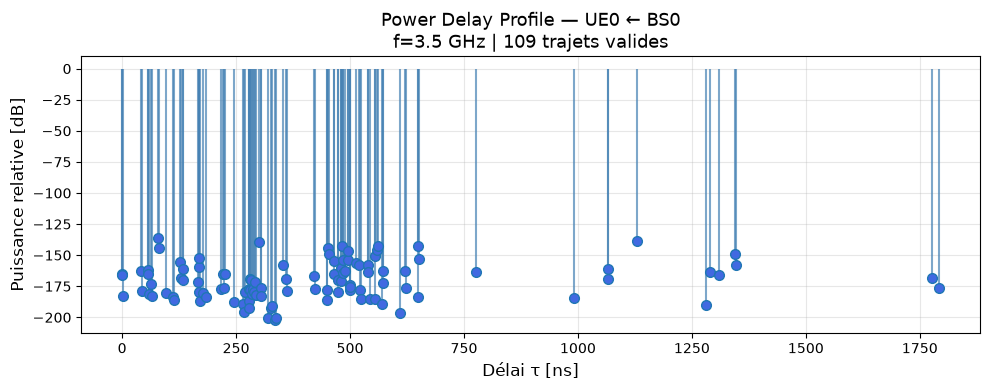

PDP sauvegardé → pdp_ue0_bs0.png


In [11]:
def plot_pdp(a_cplx: np.ndarray, tau_arr: np.ndarray,
             rx_idx: int = 0, tx_idx: int = 0,
             title: str | None = None):
    """Power Delay Profile pour un lien TX→RX donné.
    a_cplx  : [num_rx, rx_ant, num_tx, tx_ant, num_paths, num_time]
    tau_arr : [num_rx, num_tx, num_paths]
    """
    a_sel   = a_cplx[rx_idx, :, tx_idx, :, :, 0]   # [rx_ant, tx_ant, paths]
    tau_sel = tau_arr[rx_idx, tx_idx, :]             # [paths]

    power   = np.abs(a_sel)**2
    power   = power.mean(axis=(0, 1))               # moyenne antennes → [paths]

    valid   = tau_sel >= 0
    tau_ns  = tau_sel[valid] * 1e9
    pwr_db  = 10 * np.log10(power[valid] + 1e-30)

    order   = np.argsort(tau_ns)
    tau_ns  = tau_ns[order]
    pwr_db  = pwr_db[order]

    fig, ax = plt.subplots(figsize=(10, 4))
    markerline, stemlines, baseline = ax.stem(tau_ns, pwr_db, basefmt=" ")
    markerline.set_markerfacecolor("royalblue")
    markerline.set_markersize(7)
    plt.setp(stemlines, color="steelblue", alpha=0.7)

    label = title or f"UE{rx_idx} ← BS{tx_idx}"
    ax.set_xlabel("Délai τ [ns]", fontsize=12)
    ax.set_ylabel("Puissance relative [dB]", fontsize=12)
    ax.set_title(f"Power Delay Profile — {label}\n"
                 f"f={FREQUENCY_HZ/1e9:.1f} GHz | {len(tau_ns)} trajets valides",
                 fontsize=13)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig, ax


fig, ax = plot_pdp(a_complex, tau_cir, rx_idx=0, tx_idx=0)
plt.savefig(WORKSPACE / "pdp_ue0_bs0.png", dpi=150, bbox_inches="tight")
plt.show()
print("PDP sauvegardé → pdp_ue0_bs0.png")

## 7. Comparaison PDP — tous les UE

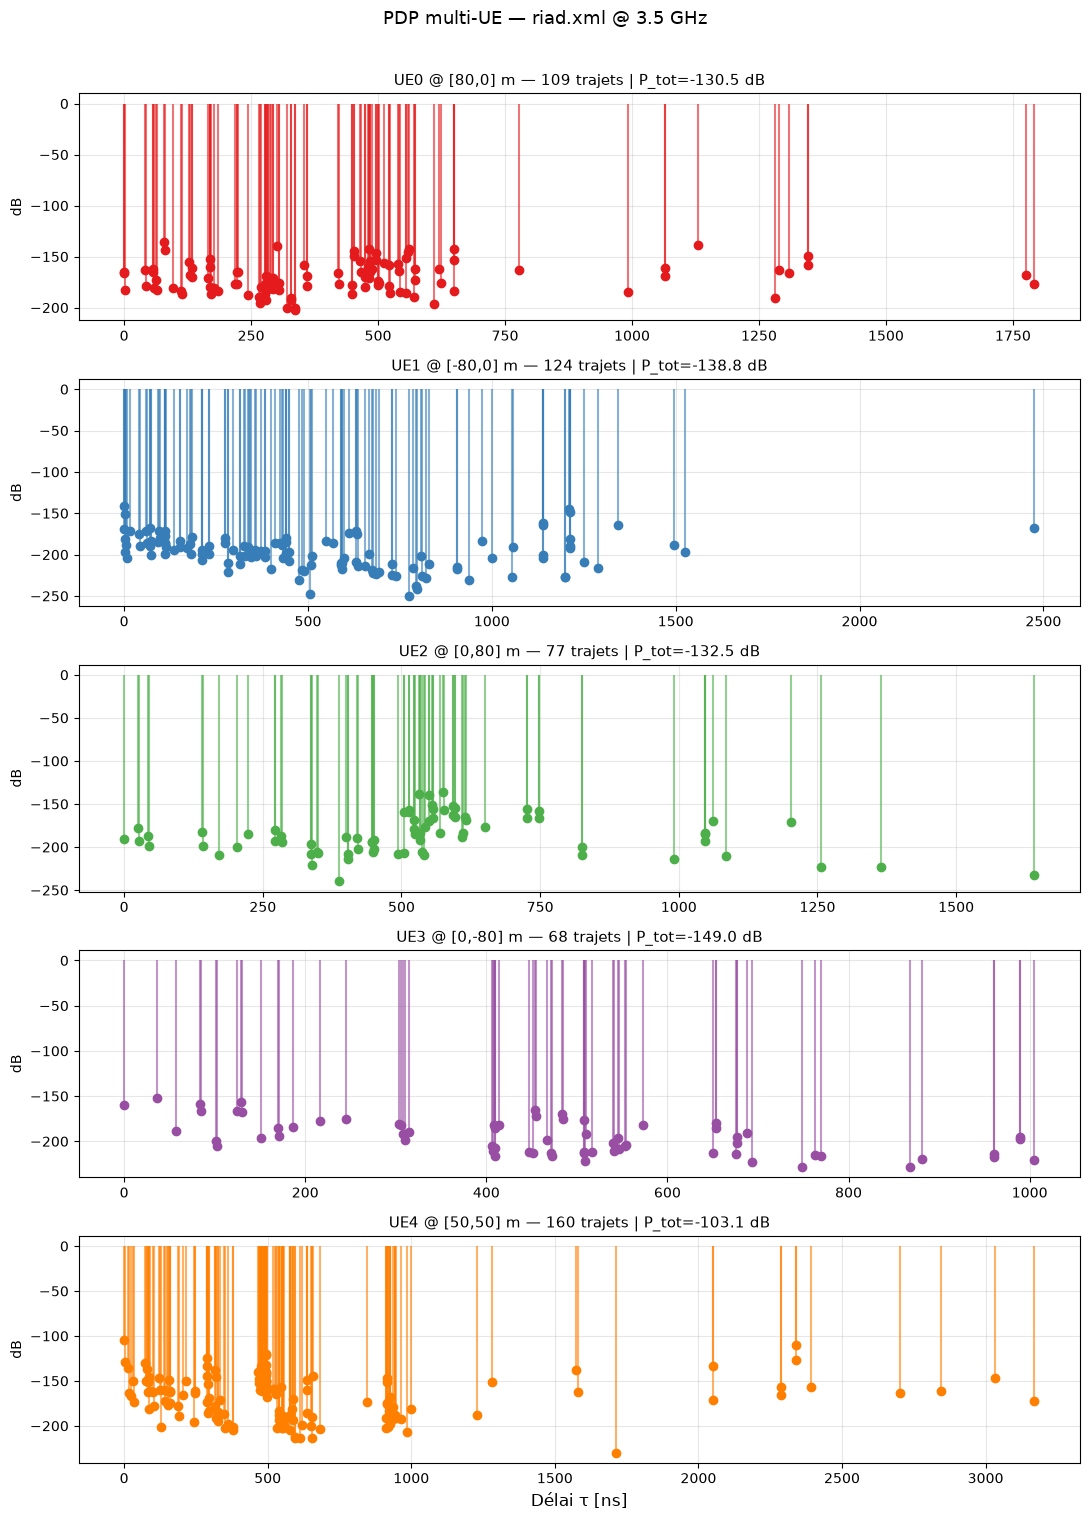

PDP multi-UE sauvegardé → pdp_all_ue.png


In [12]:
num_ue = len(RX_POSITIONS)
fig, axes = plt.subplots(num_ue, 1, figsize=(11, 3 * num_ue), sharex=False)

for rx_i, ax in enumerate(axes):
    a_sel   = a_complex[rx_i, :, 0, :, :, 0]   # [rx_ant, tx_ant, paths]
    tau_sel = tau_cir[rx_i, 0, :]               # [paths]

    power   = np.abs(a_sel)**2
    power   = power.mean(axis=(0, 1))           # [paths]

    valid   = tau_sel >= 0
    tau_ns  = tau_sel[valid] * 1e9
    pwr_db  = 10 * np.log10(power[valid] + 1e-30)

    order   = np.argsort(tau_ns)
    tau_ns  = tau_ns[order]
    pwr_db  = pwr_db[order]

    colors  = plt.cm.Set1.colors
    ml, sl, bl = ax.stem(tau_ns, pwr_db, basefmt=" ")
    plt.setp(ml, color=colors[rx_i % len(colors)], markersize=6)
    plt.setp(sl, color=colors[rx_i % len(colors)], alpha=0.6)

    pos_str = f"[{RX_POSITIONS[rx_i][0]:.0f},{RX_POSITIONS[rx_i][1]:.0f}] m"
    tot_p   = 10 * np.log10(power.sum() + 1e-30)
    ax.set_title(f"UE{rx_i} @ {pos_str} — {len(tau_ns)} trajets | P_tot={tot_p:.1f} dB",
                 fontsize=11)
    ax.set_ylabel("dB", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Délai τ [ns]", fontsize=12)
fig.suptitle(f"PDP multi-UE — riad.xml @ {FREQUENCY_HZ/1e9:.1f} GHz",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig(WORKSPACE / "pdp_all_ue.png", dpi=150, bbox_inches="tight")
plt.show()
print("PDP multi-UE sauvegardé → pdp_all_ue.png")

## 8. Carte de couverture radio (RadioMapSolver)

Le `RadioMapSolver` calcule la puissance reçue sur une grille 2D —
utile pour valider la couverture de la BS et identifier les zones d'ombre.

In [ ]:
rm_solver = RadioMapSolver()

print("Calcul de la carte de couverture...")
t0 = time.time()

# RadioMapSolver 2.x : center/size/cell_size sont des params directs du call
# PAS de radio_map= ; pas de num_samples= (c'est samples_per_tx=)
radio_map = rm_solver(
    scene,
    center=[0., 0., 1.5],          # plan horizontal à 1.5 m (hauteur UE)
    orientation=[0., 0., 0.],
    size=[300., 300.],              # 300 m × 300 m
    cell_size=[5., 5.],            # résolution 5 m
    max_depth=MAX_DEPTH,
    samples_per_tx=int(5e5),
    diffuse_reflection=False,
    los=True,
    specular_reflection=True,
    diffraction=False,
    seed=42,
)

print(f"Carte calculée en {time.time()-t0:.2f} s")

# path_gain shape : [num_tx, cells_y, cells_x]
path_gain_db = 10 * np.log10(np.array(radio_map.path_gain).squeeze() + 1e-30)
print(f"Grille : {path_gain_db.shape[0]}×{path_gain_db.shape[1]} cellules | "
      f"Path gain : [{path_gain_db[path_gain_db>-200].min():.1f}, {path_gain_db.max():.1f}] dB")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(
    path_gain_db,
    origin="lower",
    cmap="jet",
    vmin=np.percentile(path_gain_db[path_gain_db > -200], 5),
    vmax=path_gain_db.max(),
)
plt.colorbar(im, ax=ax, label="Path Gain [dB]")
ax.set_title(f"Carte de couverture — riad.xml @ {FREQUENCY_HZ/1e9:.1f} GHz\n"
             f"BS @ {TX_POS}, 300m×300m, résolution 5m", fontsize=12)
ax.set_xlabel("X [cellules × 5 m]")
ax.set_ylabel("Y [cellules × 5 m]")

# Marquer la BS au centre
cy, cx = path_gain_db.shape
ax.plot(cx // 2, cy // 2, "w^", markersize=12, label="BS (TX)")
ax.legend(fontsize=10)
fig.tight_layout()
plt.savefig(WORKSPACE / "radio_map_riad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Carte de couverture sauvegardée → radio_map_riad.png")

## 9. Paramètres ISAC — Sorties pour la Phase 3

Le ISAC (Integrated Sensing And Communications) exploite les paramètres de canal :
- **Délais** τᵢ → distance des cibles (range)
- **DoA** θᵢ, φᵢ → direction d'arrivée (localisation angulaire)
- **Doppler** fΔ,ᵢ → vitesse radiale (si objets mobiles)
- **Puissances** |aᵢ|² → intensité de réflexion (matériau, distance)

In [ ]:
import warnings

isac_params = []

for rx_i in range(num_rx):
    tau_sel  = tau_cir[rx_i, 0, :]                         # [num_paths]
    a_sel    = a_complex[rx_i, :, 0, :, :, 0]              # [rx_ant, tx_ant, paths]
    power_all = np.abs(a_sel)**2
    power_mean = power_all.mean(axis=(0, 1))                # moyenne antennes → [paths]

    valid    = tau_sel >= 0
    tau_v    = tau_sel[valid]
    power_v  = power_mean[valid]
    psum     = power_v.sum() + 1e-30

    # Delay spread (RMS)
    mean_tau = np.sum(power_v * tau_v) / psum
    rms_ds   = np.sqrt(np.sum(power_v * (tau_v - mean_tau)**2) / psum)

    # DoA : theta_t / phi_t si disponibles
    doa_theta, doa_phi = None, None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            doa_theta = np.array(paths.theta_t)[rx_i, 0, :][valid]
            doa_phi   = np.array(paths.phi_t)[rx_i, 0, :][valid]
        except Exception:
            pass

    rec = {
        "rx": f"ue{rx_i}",
        "tx": "bs0",
        "position_rx": RX_POSITIONS[rx_i],
        "num_valid_paths": int(valid.sum()),
        "delays_ns": (tau_v * 1e9).tolist(),
        "powers_db": (10 * np.log10(power_v + 1e-30)).tolist(),
        "total_power_db": float(10 * np.log10(psum)),
        "rms_delay_spread_ns": float(rms_ds * 1e9),
    }
    if doa_theta is not None:
        rec["doa_theta_deg"] = np.degrees(doa_theta).tolist()
        rec["doa_phi_deg"]   = np.degrees(doa_phi).tolist()

    isac_params.append(rec)
    print(f"UE{rx_i}: {rec['num_valid_paths']} trajets | "
          f"P_tot={rec['total_power_db']:.1f} dB | "
          f"DS_rms={rec['rms_delay_spread_ns']:.1f} ns")

print("\nParamètres ISAC extraits.")

## 10. Export Phase 2 → JSON (handoff vers Phase 3)

In [ ]:
phase2_summary = {
    "project": "SDM-VA-ISAC",
    "phase": 2,
    "scene_xml": str(SCENE_XML),
    "mitsuba_variant": mi.variant(),
    "sionna_version": sionna.__version__,
    "frequency_hz": float(FREQUENCY_HZ),
    "bandwidth_hz": float(BANDWIDTH_HZ),
    "max_depth": int(MAX_DEPTH),
    "tx_position": TX_POS,
    "rx_positions": RX_POSITIONS,
    "a_shape": list(a_complex.shape),
    "tau_shape": list(tau_cir.shape),
    "isac_per_link": isac_params,
    "validation": {
        "scene_loaded": True,
        "paths_found": int((tau_cir >= 0).sum()) > 0,
        "cir_extracted": True,
        "pdp_generated": True,
    }
}

out_path = WORKSPACE / "phase2_sionna_rt_summary.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(phase2_summary, f, indent=2)

print(f"Résumé Phase 2 sauvegardé → {out_path}")

v = phase2_summary["validation"]
print("\n=== VALIDATION PHASE 2 ===")
for k, ok in v.items():
    icon = "✓" if ok else "✗"
    print(f"  {icon}  {k}")

if all(v.values()):
    print("\n>>> Phase 2 VALIDÉE — Prêt pour la Phase 3 (fusion multimodale) <<<")
else:
    print("\n>>> Certains critères non satisfaits — vérifier les erreurs ci-dessus")